# Load data and train/test split

Everyone uses this. Run these cells first.

In [104]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
)
import matplotlib.pyplot as plt

df = pd.read_parquet("combined_preprocessed.parquet")
print(df.shape)


(6304794, 14)


In [105]:
df.head()

,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,DISTANCE,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,DELAY_CLASS,ORIGIN_STATE,DEST_STATE,DEP_HOUR
0,1,1,1,3,AA,2475.0,NaN,NaN,NaN,NaN,0,NY,CA,6
1,1,1,1,3,AA,2475.0,NaN,NaN,NaN,NaN,0,CA,NY,22
2,1,1,1,3,AA,708.0,0.0,0.0,0.0,0.0,2,WI,NC,6
3,1,1,1,3,AA,2176.0,NaN,NaN,NaN,NaN,0,PA,NV,18
4,1,1,1,3,AA,1440.0,0.0,44.0,0.0,0.0,0,IL,AZ,8


In [106]:
# Drop leakage columns (only known AFTER the flight — kept in preprocessed for EDA only)
postprocessing_cols = [
   "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY"
]

X = df.drop(columns=[c for c in postprocessing_cols + ["DELAY_CLASS"] if c in df.columns])
X["DEP_HOUR"] = X["DEP_HOUR"].replace(24, 0)
y = df["DELAY_CLASS"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Class distribution — train:")
print(y_train.value_counts(normalize=True).sort_index())
print(y_test.value_counts(normalize=True).sort_index())


Train: (5043835, 9), Test: (1260959, 9)
Class distribution — train:
DELAY_CLASS
0    0.780265
1    0.072238
2    0.066119
3    0.048023
4    0.033354
Name: proportion, dtype: float64
DELAY_CLASS
0    0.780265
1    0.072239
2    0.066120
3    0.048023
4    0.033354
Name: proportion, dtype: float64


### Data Scaling + One Hot Encoding run THIS

In [108]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


numeric_features = X_train.select_dtypes(include = ["int8", "int16", "int32", "int64", "float16", "float32", "float64"]).columns
categorical_features = X_train.select_dtypes(include = ["object"]).columns

preprocessor = ColumnTransformer(
    transformers = [
        ("num", MinMaxScaler(), numeric_features),
        ("cat", OneHotEncoder(), categorical_features)
    ])

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

### Near Miss resampling. DONT run this. Use the parquet to access the reduce training X and y sets

In [ ]:
from imblearn.under_sampling import NearMiss
from collections import Counter
nm = NearMiss(version = 2, sampling_strategy= "not minority", n_neighbors= 3)

X_res, y_res = nm.fit_resample(X_train_preprocessed, y_train)
print(Counter(y_res))

Counter({0: 168232, 1: 168232, 2: 168232, 3: 168232, 4: 168232})


ArrowInvalid: ("Could not convert <Compressed Sparse Row sparse matrix of dtype 'float64'\n\twith 9 stored elements and shape (1, 126)> with type csr_matrix: did not recognize Python value type when inferring an Arrow data type", 'Conversion failed for column 0 with type object')

In [114]:
# Convert sparse matrix to dense array, then to DataFrame with proper column names
df_res = pd.DataFrame(X_res.toarray(), columns=preprocessor.get_feature_names_out())

# Add the target column back
df_res["DELAY_CLASS"] = y_res

df_res.to_parquet('undersampled_data.parquet', index=False, compression='zstd')  

# Helper function so everyone reports the same metrics.

In [57]:
CLASS_NAMES = ['No Delay', '15-29 min', '30-59 min', '1-2 hr', '2+ hr']

def evaluate(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"F1:        {f1_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted'):.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(cm, cmap='Blues')
    for i in range(len(CLASS_NAMES)):
        for j in range(len(CLASS_NAMES)):
            ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center', fontsize=10)
    ax.set_xticks(range(len(CLASS_NAMES)))
    ax.set_yticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{name} — Confusion Matrix')
    plt.tight_layout()
    plt.show()

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, y_pred, average='weighted', zero_division=0),
        "F1": f1_score(y_test, y_pred, average='weighted', zero_division=0),
        "AUC-ROC": roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted'),
    }

In [58]:
results = []

**most difficult task -- what features should we use??**

**what features we should drop?? one by one**

**and then, One-hot encoding so that we can add the destination in there**

---
# Sam — Logistic Regression

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# TODO (Sam):
# 1. Create model with: max_iter=1000, class_weight='balanced', random_state=42
# 2. Fit on X_train, y_train
# 3. results.append(evaluate('Logistic Regression', lr_model, X_test, y_test))

X_train_s = X_train.sample(n=500_000, random_state=42)
y_train_s = y_train.loc[X_train_s.index]
X_train_s = X_train_s.to_numpy(dtype=np.float32)
X_test_np = X_test.to_numpy(dtype=np.float32)

lr_model = Pipeline([
    ('scaler', StandardScaler(with_mean=False)), 
    ('clf', LogisticRegression(
        solver='saga',
        max_iter=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,  
    )),
])
lr_model.fit(X_train_s, y_train_s)

Pipeline(steps=[('scaler', StandardScaler(with_mean=False)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=200,
                                    n_jobs=-1, random_state=42,
                                    solver='saga'))])

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


--- Logistic Regression ---
Accuracy:  0.0735
Precision: 0.7526
Recall:    0.0735
F1:        0.0164
AUC-ROC:   0.6420

              precision    recall  f1-score   support

    No Delay       0.95      0.00      0.00    983882
   15-29 min       0.07      0.88      0.13     91090
   30-59 min       0.00      0.00      0.00     83374
      1-2 hr       0.08      0.19      0.11     60555
       2+ hr       0.06      0.01      0.01     42058

    accuracy                           0.07   1260959
   macro avg       0.23      0.22      0.05   1260959
weighted avg       0.75      0.07      0.02   1260959



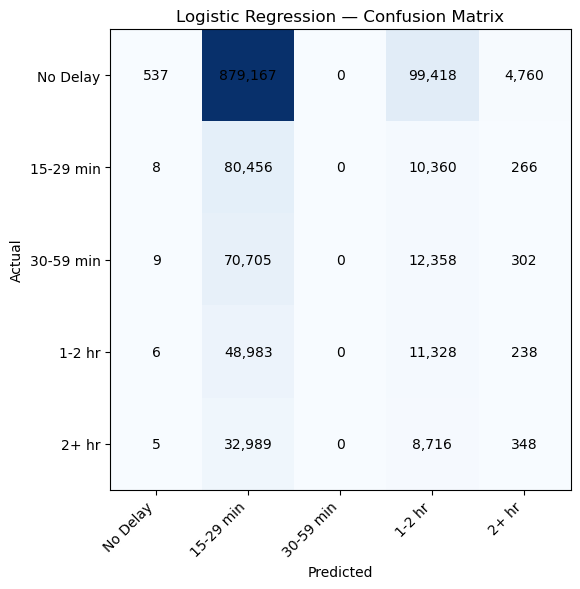

In [9]:
results.append(evaluate('Logistic Regression', lr_model, X_test, y_test))

Text(0.5, 1.0, 'Top 15 Features by |Coefficient| — Logistic Regression')

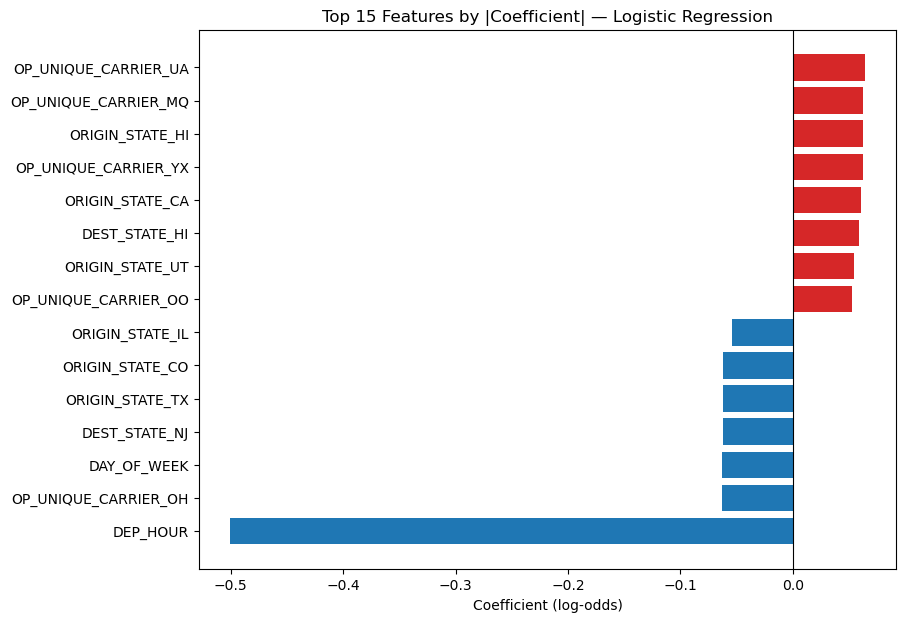

In [10]:
# TODO (Sam): Feature importance plot
# 1. Get coefficients from lr_model.coef_[0]
# 2. Find the top 15 by absolute value
# 3. Plot as horizontal bar chart
coefs = lr_model.named_steps['clf'].coef_[0]
feature_names = X_train.columns

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coefs,
    'abs_coef': np.abs(coefs),
})

top15 = coef_df.nlargest(15, 'abs_coef').sort_values('coef')

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#d62728' if c > 0 else '#1f77b4' for c in top15['coef']]
ax.barh(top15['feature'], top15['coef'], color=colors)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Top 15 Features by |Coefficient| — Logistic Regression')

---
# Wahid — Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)

results.append(evaluate('Random Forest', rf_model, X_test, y_test))

In [ ]:
# TODO (Wahid): Feature importance plot
# 1. Get importances from rf_model.feature_importances_
# 2. Find the top 15
# 3. Plot as horizontal bar chart


---
# Aryan — XGBoost

In [11]:
import xgboost as xgb

# XGBoost Model — Using full train/test sets from Cell 3 (no sampling)
# 1. Use X_train, X_test, y_train, y_test directly
# 2. Select only numerical columns
# 3. Create XGBoost classifier with class balancing to reduce majority class bias
# 4. Fit and append results using evaluate()

# Select only numerical columns
X_train_xgb = X_train.select_dtypes(include=[np.number]).to_numpy(dtype=np.float32)
X_test_xgb = X_test.select_dtypes(include=[np.number]).to_numpy(dtype=np.float32)
y_train_xgb = y_train.values

# Compute inverse class frequency weights to address class imbalance
class_counts = np.bincount(y_train_xgb)
class_weights = len(y_train_xgb) / (len(class_counts) * class_counts)
sample_weights = class_weights[y_train_xgb]

xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=5,
    max_depth=8,
    learning_rate=0.15,
    n_estimators=150,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
)
xgb_model.fit(X_train_xgb, y_train_xgb, sample_weight=sample_weights, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.15, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=-1, num_class=5, ...)

--- XGBoost ---
Accuracy:  0.4993
Precision: 0.7211
Recall:    0.4993
F1:        0.5754
AUC-ROC:   0.7214

              precision    recall  f1-score   support

    No Delay       0.89      0.57      0.70    983882
   15-29 min       0.12      0.27      0.17     91090
   30-59 min       0.12      0.13      0.12     83374
      1-2 hr       0.10      0.24      0.14     60555
       2+ hr       0.10      0.44      0.16     42058

    accuracy                           0.50   1260959
   macro avg       0.27      0.33      0.26   1260959
weighted avg       0.72      0.50      0.58   1260959



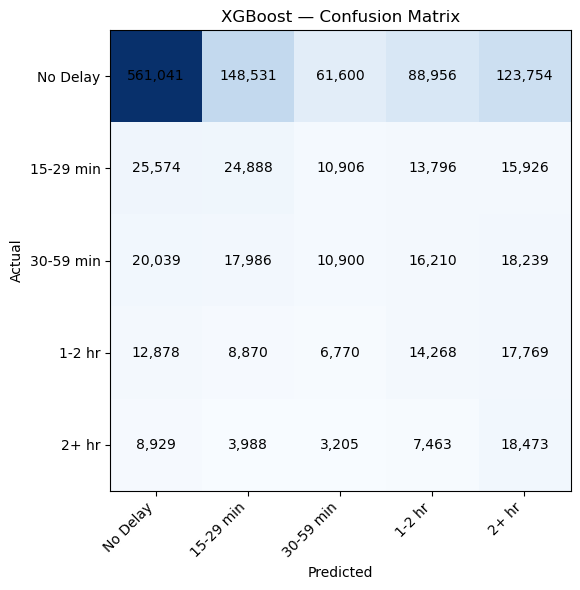

In [12]:
results.append(evaluate('XGBoost', xgb_model, X_test_xgb, y_test))

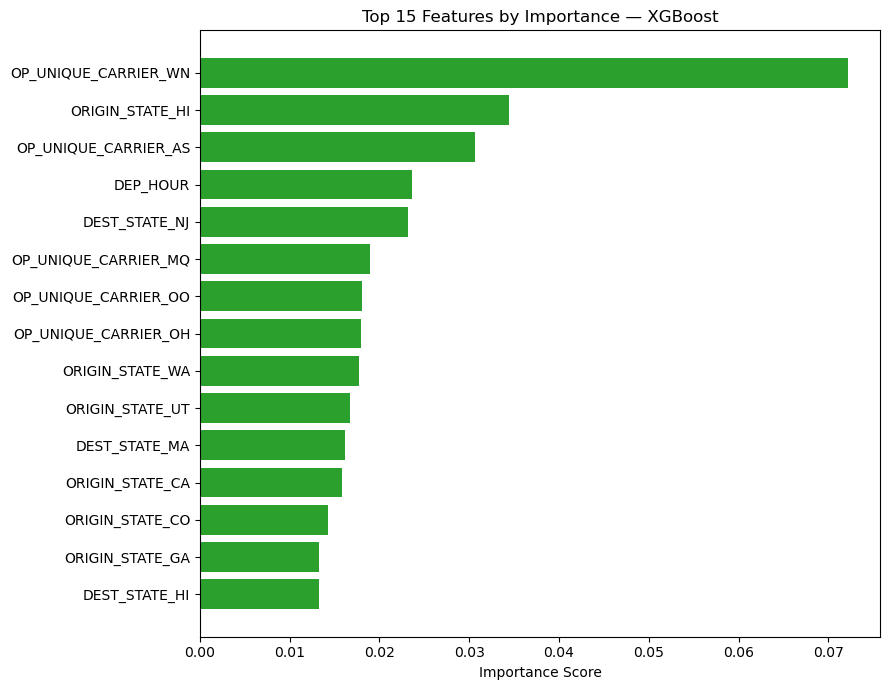

In [13]:
# TODO (Aryan): Feature importance plot — For numerical features only
# 1. Get importances from xgb_model.feature_importances_
# 2. Map to numerical feature names
# 3. Find the top 15
# 4. Plot as horizontal bar chart

importances = xgb_model.feature_importances_
numerical_features = X_train.select_dtypes(include=[np.number]).columns

importance_df = pd.DataFrame({
    'feature': numerical_features,
    'importance': importances,
})

top15 = importance_df.nlargest(15, 'importance').sort_values('importance')

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top15['feature'], top15['importance'], color='#2ca02c')

ax.set_xlabel('Importance Score')
ax.set_title('Top 15 Features by Importance — XGBoost')
plt.tight_layout()
plt.show()

---
# Dennis — RNN

Needs `pip install tensorflow`.

## Naive Bayes

In [43]:
from sklearn.preprocessing import OrdinalEncoder

def pipeline(data, encoder = None):

    cat_cols_idx = []
    for col_idx, col in enumerate(data.columns):
        if col != "DISTANCE":
            cat_cols_idx.append(col_idx)

    if encoder is None:
        encoder = OrdinalEncoder(dtype = int)
        data.iloc[:, cat_cols_idx] = encoder.fit_transform(data.iloc[:, cat_cols_idx])
    else:
        data.iloc[:, cat_cols_idx] = encoder.transform(data.iloc[:, cat_cols_idx])

    data = data.apply(pd.to_numeric)

    return data, encoder


In [52]:
df_nb = pd.read_parquet("combined_preprocessed_noleakage.parquet")

leak_cols = [
    "DEP_DELAY",
    "ARR_DELAY",
    "DEP_DEL15",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "DIVERTED",
    "DEST_AIRPORT_SEQ_ID",
]
X = df_nb.drop(columns=[c for c in leak_cols + ["DELAY_CLASS"] if c in df.columns])
X = X.drop(columns = "YEAR")
X["DEP_HOUR"] = X["DEP_HOUR"].replace(24, 0)

y = df_nb["DELAY_CLASS"]



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)


In [62]:
encoder = OrdinalEncoder(dtype=int)
cat_cols = [col for col in X.columns if col != "DISTANCE"]
encoder.fit(X[cat_cols])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

min_count = y_train.value_counts().min()
X_train_bal = X_train.groupby(y_train).apply(lambda x: x.sample(min_count, random_state=42)).reset_index(drop=True)
y_train_bal = y_train.groupby(y_train).apply(lambda x: x.sample(min_count, random_state=42)).reset_index(drop=True)

def pipeline(data, encoder):
    cat_cols_idx = [i for i, col in enumerate(data.columns) if col != "DISTANCE"]
    data.iloc[:, cat_cols_idx] = encoder.transform(data.iloc[:, cat_cols_idx])
    data = data.apply(pd.to_numeric)
    return data

X_train_bal = pipeline(X_train_bal, encoder)
X_test = pipeline(X_test, encoder)

C:\Users\denni\AppData\Local\Temp\ipykernel_27392\836703793.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[2 3 2 ... 2 1 3]' has dtype incompatible with int8, please explicitly cast to a compatible dtype first.
  data.iloc[:, cat_cols_idx] = encoder.transform(data.iloc[:, cat_cols_idx])
C:\Users\denni\AppData\Local\Temp\ipykernel_27392\836703793.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[5 9 5 ... 5 2 9]' has dtype incompatible with int8, please explicitly cast to a compatible dtype first.
  data.iloc[:, cat_cols_idx] = encoder.transform(data.iloc[:, cat_cols_idx])
C:\Users\denni\AppData\Local\Temp\ipykernel_27392\836703793.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 5  8 28 ...  6  3 23]' has dtype incompatible with int8, please explicitly cast

In [67]:
X_train

,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,DISTANCE,ORIGIN_STATE,DEST_STATE,DEP_HOUR
3264295,2,6,24,2,DL,1020.0,MN,NY,6
863092,1,2,20,4,OO,588.0,CA,UT,13
1290570,2,4,14,1,WN,854.0,CO,CA,18
2514459,3,8,17,7,AA,1846.0,CA,IL,6
2577437,3,8,20,3,G4,841.0,FL,IL,16
...,...,...,...,...,...,...,...,...,...
4020466,3,9,1,1,F9,758.0,DC,FL,21
2988344,2,6,10,2,UA,783.0,CT,IL,6
3290386,2,6,25,3,UA,200.0,MA,NJ,19
1405044,2,4,20,7,WN,480.0,CA,CA,15


In [65]:
from mixed_naive_bayes import MixedNB

cat_cols_idx = [i for i, col in enumerate(X_train.columns) if col != "DISTANCE"]

nb_clf = MixedNB(categorical_features= cat_cols_idx)

nb_clf.fit(X_train_bal, y_train_bal)
predictions = nb_clf.predict(X_test)

--- Naive Bayes ---
Accuracy:  0.3939
Precision: 0.7080
Recall:    0.3939
F1:        0.4841
AUC-ROC:   0.6670

              precision    recall  f1-score   support

    No Delay       0.88      0.44      0.59    983882
   15-29 min       0.11      0.32      0.16     91090
   30-59 min       0.10      0.08      0.09     83374
      1-2 hr       0.08      0.19      0.11     60555
       2+ hr       0.06      0.40      0.10     42058

    accuracy                           0.39   1260959
   macro avg       0.25      0.29      0.21   1260959
weighted avg       0.71      0.39      0.48   1260959



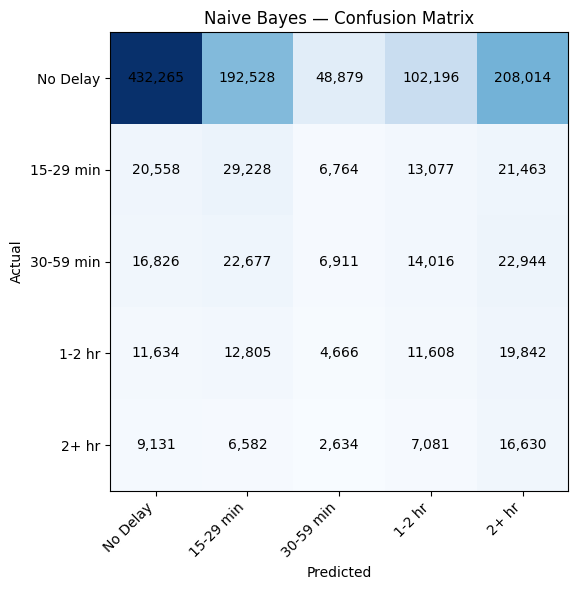

In [66]:
results.append(evaluate(name= "Naive Bayes", model = nb_clf, X_test = X_test , y_test = y_test))

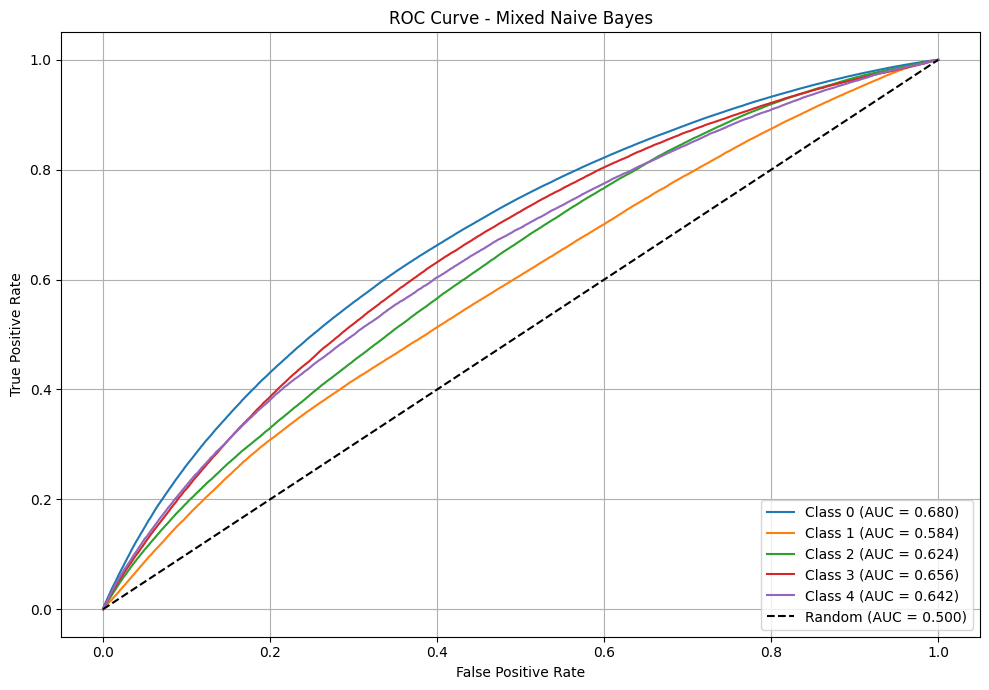

In [68]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Get predicted probabilities
y_proba = nb_clf.predict_proba(X_test)

# Binarize y_test for multiclass ROC
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

# Plot ROC for each class
plt.figure(figsize=(10, 7))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {cls} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random (AUC = 0.500)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Mixed Naive Bayes")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

### RNN

In [ ]:
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

# TODO (Dennis): Preprocessing
# 1. Scale X_train and X_test with StandardScaler
# 2. Reshape to 3D: (samples, 1, features) — RNN expects 3D input


In [ ]:
# TODO (Dennis): Build and train
# 1. Build Sequential: SimpleRNN(64) -> Dropout(0.3) -> Dense(32) -> Dense(5, softmax)
# 2. Compile with optimizer='adam', loss='sparse_categorical_crossentropy'
# 3. Fit with epochs=10, batch_size=1024, validation_split=0.1


In [ ]:
# TODO (Dennis): Evaluate
# 1. Get probabilities: y_prob = rnn_model.predict(X_test_rnn)  # shape (N, 5)
# 2. Get predictions: y_pred = y_prob.argmax(axis=1)
# 3. Print weighted metrics (accuracy, precision, recall, F1, AUC-ROC with multi_class='ovr')
# 4. Plot confusion matrix (5x5)
# 5. Append results dict to results list


---
# Compare all models

In [ ]:
comparison = pd.DataFrame(results).set_index('Model')
comparison.round(4)

In [ ]:
comparison.plot.bar(figsize=(10, 5), title='Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()